# Pump and Treat - Well System Model: Flopy Iterations

Strategy 1.1: Performing PAT with existing wells and constant pumping rate of -25.0 m3/day.

Strategy 1.?...: Iterate the model until reaching values closer to threshold 

# Start setting up the model 

### Magic commands - auto reload of the model each time 

In [1]:
%load_ext autoreload

In [2]:
%autoreload 2

### Import from pymf6tools the functions to run, get and visualize simulation results

In [3]:
from pathlib import Path 
from pymf6.mf6 import MF6
import pandas as pd 
from functools import partial 
import numpy as np 

from pymf6_tools.make_model import run_simulation, get_simulation


from pymf6_tools.base_model import make_model_data
from pymf6_tools.make_model import make_input, run_simulation, get_simulation
from pymf6_tools.plotting import show_heads, show_well_head, show_bcs

In [4]:
from pymf6_tools.plotting import (
show_heads, show_well_head, show_concentration, show_bcs, 
show_bot_elevations, show_river_stages, contour_bot_elevations, 
plot_spec_discharge)
import pymf6_tools

## Strategy 1.2: Solving it with unregulated pumping campaign

*Iterative Reduction*: Employing a systematic search methodology, the pumping rate was successively halved in the initial stages to efficiently narrow down the solution space. The sequence of tested pumping rates was:

Iteration 1: 50.00 - below

Iteration 2: 25.00 - below

Iteration 3: 12.00 - below

Iteration 4: 6.00 - below 

Iteration 5: 3.00 - below 

Iteration 6: 1.50 - below 

Iteration 7: 0.75 - below

Iteration 8: 0.38 - above 

Iteration 9: 0.60 - above 

Iteration 10: 0.66 - below 

*Final Result*: After nine iterative model runs, a pumping rate of 0.66 was identified as the optimal solution. This value successfully contains the contaminant plume, bringing the simulated concentration to a value close to the regulatory threshold.

### Set path for the model with the wells 

In [5]:
model_path = r'models/mf6/pumptreat_0p66p'
model_name = 'pumptreat'

### Run simulation

In [6]:
run_simulation(model_path, verbosity_level=0)

### Location of the wells 

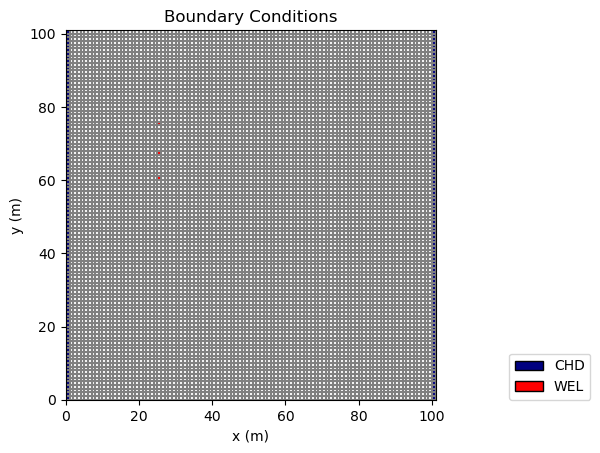

In [7]:
show_bcs(model_path, name=model_name, bc_names=('chd','wel'))

This graph shows the location of the boundary conditions at the right and left side of the domain, and the location of the wells that will be used of the PAT. 

### Specific Discharge - Interactive graph (layer and time)
Specify the layer and time of the simulation to be visualized.

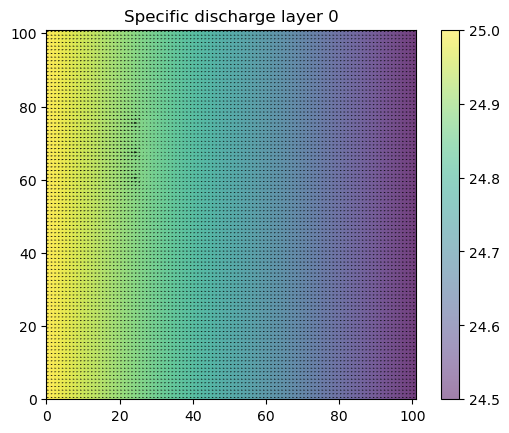

In [8]:
plot_spec_discharge(model_path, model_name, layer=0, times=249)

This graph shows the specific discharge of the layer 1 of the model, indicating the disturbance of flow caused by the wells. 

### Groundwater level 

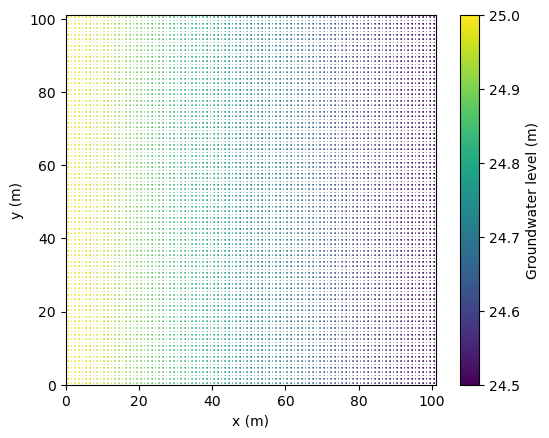

In [9]:
show_heads(model_path, model_name, show_wells=False, kstpkper=(249, 1))

This graph shows the groundwater flow of the domain.

### Concentration

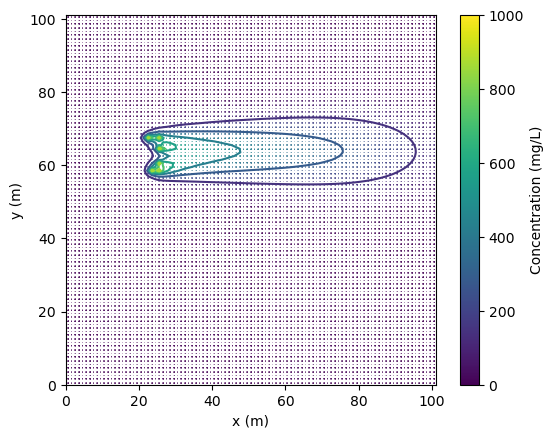

In [10]:
show_concentration(model_path, model_name, show_wells=False , show_arrows=True, show_rivers=False,  kstpkper=(249, 1))

### Limitations of the Unregulated Pump-and-Treat Approach

An unregulated pump-and-treat (PAT) strategy, where extraction wells operate continuously at maximum capacity, can be both inefficient and potentially counterproductive. Without adaptive control, this approach cannot respond to changes in contaminant levels, leading to unnecessary energy use and treatment of clean water. Moreover, excessive pumping risks altering the natural hydraulic gradient, potentially drawing contaminants toward clean areas, including the municipal boundary. In low-permeability zones, it may also reduce effectiveness by bypassing trapped pollutants. Therefore, a controlled, feedback-based strategy is essential to optimize remediation efforts, contain the contamination plume, and maintain water quality standards efficiently.

### Why running the control script?

If there is no control over the pumping of the wells and we will have to iterate methodically we would extract *3 375 m³*, but if the simulation is being controlled by the concentration values at the observation well, then the volume to be extracted should be *! Let's find the most economic strategy by controlling the model!